In [1]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sys.path.append('../bin')
from bin.functions import *
from bin.permutation import *
from bin.markov_permutation import *
from bin.entropy import *
from bin.criterions import *
np.seterr(all = 'ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [26]:
metric = pd.read_csv("../src/metrics&entropy_M4.csv", index_col=0)
metric.head()

,perm_ent3,perm_ent4,mse,mape,sym_test,w_perm_ent4,smape,mase,max_diff,amplitude,mean,variance,adf_test_pvalue,kpss_test_pvalue,sym_test1,sym_test2,sym_pv,sym_pv1,length
V1,,,,,,,,,,,,,,,,,,,
Y1,0.697843,0.539401,4993.838193,0.009190,False,-0.0,0.009146,0.600416,232.3,2566.8,6523.738710,7.535744e+05,0.113077,0.010000,False,False,4.144913e-04,3.454094e-05,31
Y2,0.816579,0.705971,12899.948420,0.084814,False,-0.0,0.088896,0.552155,599.0,1533.0,1346.387097,1.432428e+05,0.110802,0.096658,True,False,2.962458e-02,2.468715e-03,31
Y3,0.000000,0.000000,3476.611770,0.005390,False,-0.0,0.005387,0.254877,320.0,5620.0,5595.806452,2.732452e+06,0.951878,0.010000,False,False,8.686385e-13,7.238654e-14,31
Y4,0.166740,0.144179,16100.535285,0.010972,False,-0.0,0.010918,0.510635,440.0,6290.0,6599.032258,3.248222e+06,0.988328,0.010000,False,False,2.177485e-10,1.814571e-11,31
Y5,0.478736,0.395644,10617.608987,0.010394,False,-0.0,0.010289,0.436703,590.0,4860.0,4012.580645,1.727553e+06,0.997930,0.010000,False,False,3.119669e-06,2.599725e-07,31


In [27]:
metric.shape

(100000, 19)

In [16]:
new_test = pd.read_csv("../src/quater_double_symmetric_test.csv", index_col=0)
new_test.head()

,equals_res,chi2_res
Q1,True,True
Q2,True,True
Q3,True,True
Q4,True,True
Q5,True,False


In [12]:
new_test.shape

(100000, 3)

In [44]:
metric[metric['length'] > 1000].index

Index(['W1', 'W2', 'W3', 'W4', 'W5', 'W6', 'W7', 'W8', 'W9', 'W19',
       ...
       'D3730', 'D3735', 'D3744', 'D3819', 'D4051', 'D4092', 'D4099', 'D4196',
       'D4226', 'D4227'],
      dtype='object', name='V1', length=2872)

In [46]:
new_test1 = new_test.loc[metric[metric['length'] > 1000].index]
new_test2 = new_test.loc[metric[metric['length'] > 700].index]
new_test3 = new_test.loc[metric[metric['length'] > 300].index]
new_test4 = new_test.loc[metric[metric['length'] > 100].index]

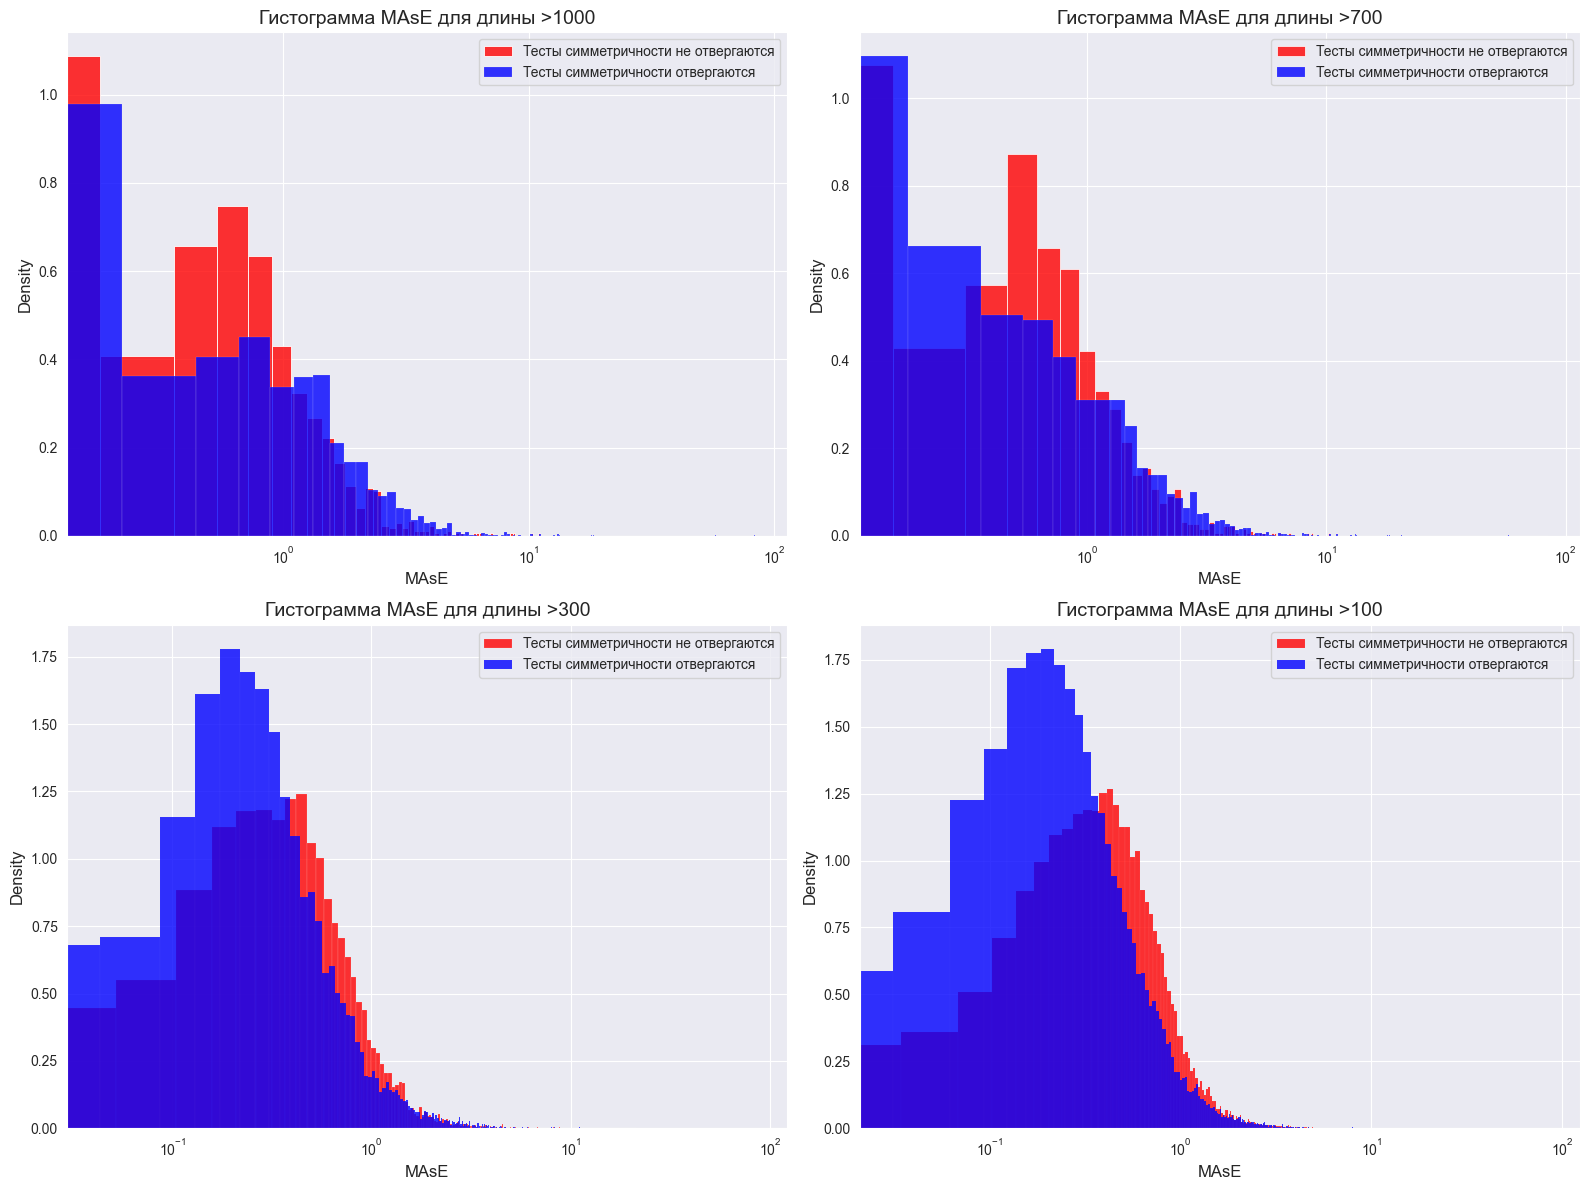

In [52]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12))  # Создаем сетку 2x2 для 4 графиков

# Первый график
sns.histplot(metric.loc[new_test1.index][new_test1['equals_res'] == True]['mase'], 
             stat='density', color='red', alpha=0.8, label='Тесты симметричности не отвергаются', ax=axs[0, 0])
sns.histplot(metric.loc[new_test1.index][new_test1['equals_res'] == False]['mase'], 
             stat='density', color='blue', alpha=0.8, label='Тесты симметричности отвергаются', ax=axs[0, 0])
axs[0, 0].set_title('Гистограмма MAsE для длины >1000', fontsize=14)
axs[0, 0].set_xlabel('MAsE', fontsize=12)
axs[0, 0].set_ylabel('Density', fontsize=12)
axs[0, 0].set_xscale('log')  # Логарифмическая шкала по оси X
axs[0, 0].legend()
axs[0, 0].grid(True)

# Второй график
sns.histplot(metric.loc[new_test2.index][new_test2['equals_res'] == True]['mase'], 
             stat='density', color='red', alpha=0.8, label='Тесты симметричности не отвергаются', ax=axs[0, 1])
sns.histplot(metric.loc[new_test2.index][new_test2['equals_res'] == False]['mase'], 
             stat='density', color='blue', alpha=0.8, label='Тесты симметричности отвергаются', ax=axs[0, 1])
axs[0, 1].set_title('Гистограмма MAsE для длины >700', fontsize=14)
axs[0, 1].set_xlabel('MAsE', fontsize=12)
axs[0, 1].set_ylabel('Density', fontsize=12)
axs[0, 1].set_xscale('log')  # Логарифмическая шкала по оси X
axs[0, 1].legend()
axs[0, 1].grid(True)

# Третий график
sns.histplot(metric.loc[new_test3.index][new_test3['equals_res'] == True]['mase'], 
             stat='density', color='red', alpha=0.8, label='Тесты симметричности не отвергаются', ax=axs[1, 0])
sns.histplot(metric.loc[new_test3.index][new_test3['equals_res'] == False]['mase'], 
             stat='density', color='blue', alpha=0.8, label='Тесты симметричности отвергаются', ax=axs[1, 0])
axs[1, 0].set_title('Гистограмма MAsE для длины >300', fontsize=14)
axs[1, 0].set_xlabel('MAsE', fontsize=12)
axs[1, 0].set_ylabel('Density', fontsize=12)
axs[1, 0].set_xscale('log')  # Логарифмическая шкала по оси X
axs[1, 0].legend()
axs[1, 0].grid(True)

# Четвертый график
sns.histplot(metric.loc[new_test4.index][new_test4['equals_res'] == True]['mase'], 
             stat='density', color='red', alpha=0.8, label='Тесты симметричности не отвергаются', ax=axs[1, 1])
sns.histplot(metric.loc[new_test4.index][new_test4['equals_res'] == False]['mase'], 
             stat='density', color='blue', alpha=0.8, label='Тесты симметричности отвергаются', ax=axs[1, 1])
axs[1, 1].set_title('Гистограмма MAsE для длины >100', fontsize=14)
axs[1, 1].set_xlabel('MAsE', fontsize=12)
axs[1, 1].set_ylabel('Density', fontsize=12)
axs[1, 1].set_xscale('log')  # Логарифмическая шкала по оси X
axs[1, 1].legend()
axs[1, 1].grid(True)

# Увеличиваем расстояние между графиками
plt.tight_layout()
plt.savefig('../src/eqmase4.png')
plt.show()


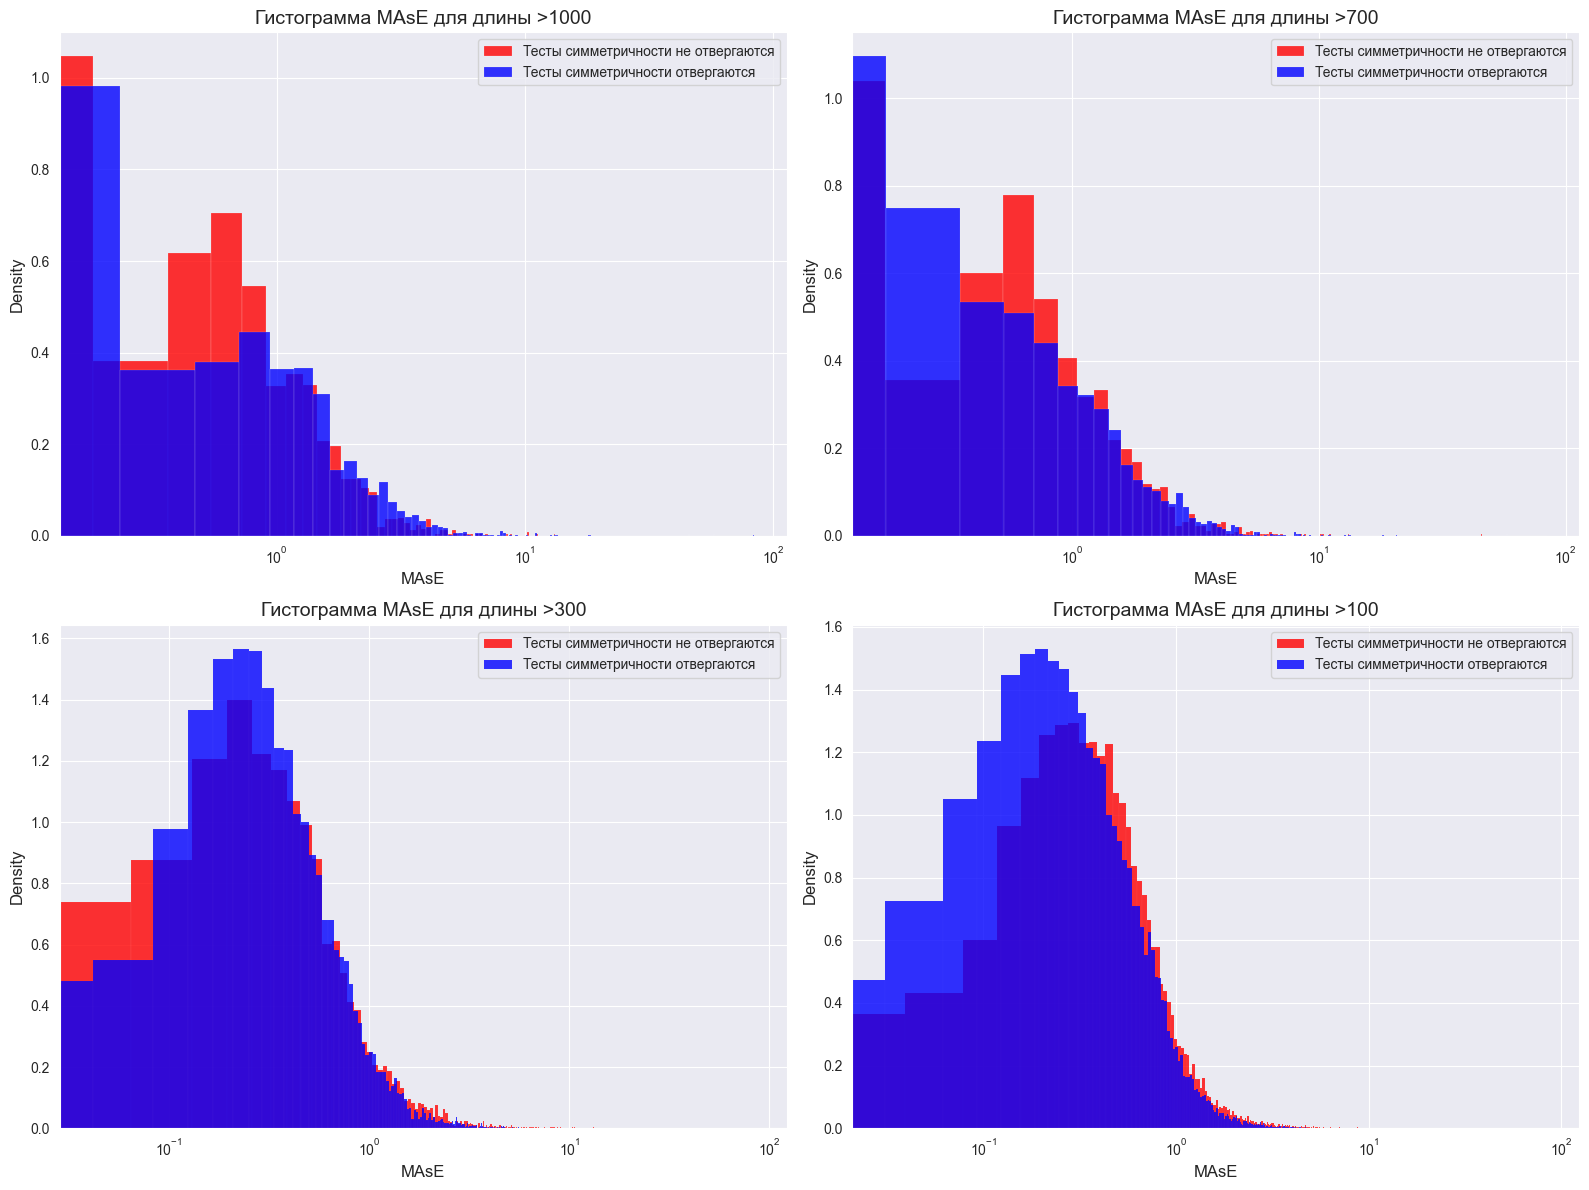

In [53]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12))  # Создаем сетку 2x2 для 4 графиков

# Первый график
sns.histplot(metric.loc[new_test1.index][new_test1['chi2_res'] == True]['mase'], 
             stat='density', color='red', alpha=0.8, label='Тесты симметричности не отвергаются', ax=axs[0, 0])
sns.histplot(metric.loc[new_test1.index][new_test1['chi2_res'] == False]['mase'], 
             stat='density', color='blue', alpha=0.8, label='Тесты симметричности отвергаются', ax=axs[0, 0])
axs[0, 0].set_title('Гистограмма MAsE для длины >1000', fontsize=14)
axs[0, 0].set_xlabel('MAsE', fontsize=12)
axs[0, 0].set_ylabel('Density', fontsize=12)
axs[0, 0].set_xscale('log')  # Логарифмическая шкала по оси X
axs[0, 0].legend()
axs[0, 0].grid(True)

# Второй график
sns.histplot(metric.loc[new_test2.index][new_test2['chi2_res'] == True]['mase'], 
             stat='density', color='red', alpha=0.8, label='Тесты симметричности не отвергаются', ax=axs[0, 1])
sns.histplot(metric.loc[new_test2.index][new_test2['chi2_res'] == False]['mase'], 
             stat='density', color='blue', alpha=0.8, label='Тесты симметричности отвергаются', ax=axs[0, 1])
axs[0, 1].set_title('Гистограмма MAsE для длины >700', fontsize=14)
axs[0, 1].set_xlabel('MAsE', fontsize=12)
axs[0, 1].set_ylabel('Density', fontsize=12)
axs[0, 1].set_xscale('log')  # Логарифмическая шкала по оси X
axs[0, 1].legend()
axs[0, 1].grid(True)

# Третий график
sns.histplot(metric.loc[new_test3.index][new_test3['chi2_res'] == True]['mase'], 
             stat='density', color='red', alpha=0.8, label='Тесты симметричности не отвергаются', ax=axs[1, 0])
sns.histplot(metric.loc[new_test3.index][new_test3['chi2_res'] == False]['mase'], 
             stat='density', color='blue', alpha=0.8, label='Тесты симметричности отвергаются', ax=axs[1, 0])
axs[1, 0].set_title('Гистограмма MAsE для длины >300', fontsize=14)
axs[1, 0].set_xlabel('MAsE', fontsize=12)
axs[1, 0].set_ylabel('Density', fontsize=12)
axs[1, 0].set_xscale('log')  # Логарифмическая шкала по оси X
axs[1, 0].legend()
axs[1, 0].grid(True)

# Четвертый график
sns.histplot(metric.loc[new_test4.index][new_test4['chi2_res'] == True]['mase'], 
             stat='density', color='red', alpha=0.8, label='Тесты симметричности не отвергаются', ax=axs[1, 1])
sns.histplot(metric.loc[new_test4.index][new_test4['chi2_res'] == False]['mase'], 
             stat='density', color='blue', alpha=0.8, label='Тесты симметричности отвергаются', ax=axs[1, 1])
axs[1, 1].set_title('Гистограмма MAsE для длины >100', fontsize=14)
axs[1, 1].set_xlabel('MAsE', fontsize=12)
axs[1, 1].set_ylabel('Density', fontsize=12)
axs[1, 1].set_xscale('log')  # Логарифмическая шкала по оси X
axs[1, 1].legend()
axs[1, 1].grid(True)

# Увеличиваем расстояние между графиками
plt.tight_layout()
plt.savefig('../src/chimase4.png')
plt.show()
